In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=api_key, temperature=0.7)

Google api key is set


In [16]:
from typing import TypedDict, List, Annotated, Optional
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from langgraph.graph.message import BaseMessage,add_messages

class llm_schema(BaseModel):
    question: Optional[str] = Field(description="question that needs to be answered")
    path: Optional[str] = Field(description="This holds path of the document the needs to be searched")
    query: Optional[str] = Field(description="Simple query usualyy for web search or semantic memory tools")

class graph_schema(TypedDict):
    query: Annotated[List[BaseMessage], add_messages]
    question: str
    documents: List[Document]
    result: str
    path: str
    tool_calls: list

llm_with_schema = llm.with_structured_output(llm_schema)

In [17]:
from typing import Optional
from langchain_core.tools import tool
from memory import LocalMemory
from tavily import TavilyClient

tavily_api_key = os.getenv("TAVILY_API_KEY")

tavily_client = TavilyClient(
    api_key=tavily_api_key
)

memory = LocalMemory()

@tool
def retriever_embedding_tool(question: str, path: str):
    """
    Retrieve relevant information from a specific local document.

    Use this tool when the user asks a question about a PDF, DOCX,
    TXT, Markdown file, or other provided document.

    Args:
        question: The exact question to answer using the document.
        path: The complete filesystem path to the document.
    """
    retrieve.file_loader(path)
    retrieve.text_splitting()
    retrieve.model_calling()

    result = retrieve.vector_embedding(question)

    return result

@tool
def memory_embedding_tool():
    """
    Tool used to retrieve information from stored information using memory vector embedding from local memory
    """

@tool
def local_conversation_memory_tool(
    timestamp: Optional[str] = None,
    limit: Optional[int] = None,
    search_term: Optional[str] = None
):
    """
    Retrieve conversations from local conversation history.

    Use this tool when the user wants to inspect previous conversations.

    Examples:
    - "Show conversations from 8 Aug 2026"
    - "Show my last 5 conversations"
    - "Find previous conversations about LangGraph"

    Args:
        timestamp: Date/time filter.
        limit: Maximum number of conversations to return.
        search_term: Keyword or topic to filter conversations.
    """
    return memory.load_memory(
        timestamp=timestamp,
        limit=limit,
        search_term=search_term
    )

@tool
def web_search_tool(query: str, max_results: int = 5):
    """
    Search the web for current or external information.

    Use this tool when the user asks for information that may require
    current, recent, or internet-based knowledge.

    Examples:
    - "What is the latest LangGraph version?"
    - "Search for AI agent developer jobs in Dubai."
    - "What happened in the latest OpenAI announcement?"

    Args:
        query: The search query to perform.
        max_results: Maximum number of search results to return.
    """
    response = tavily_client.search(
        query=query,
        max_results=max_results
    )

    return response["results"]


In [18]:
tools = [retriever_embedding_tool, memory_embedding_tool, local_conversation_memory_tool, web_search_tool]

llm_with_tool = llm.bind_tools(tools)


In [19]:
from RagIntegration import RagRetriever
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import ToolMessage
retrieve = RagRetriever()

def retriever_node(state: graph_schema) -> graph_schema:
    query = state['query']

    response = llm_with_tool.invoke(query)
    structured = llm_with_schema.invoke(query)
    
    return {
        "question": structured.question,
        "path": structured.path,
        "tool_calls": response.tool_calls
    }


def tool_node(state:graph_schema) -> graph_schema:
    tool_calls = state['tool_calls']
    tool_by_name = {tool.name: tool for tool in tools}

    documents = []
    
    for tool_call in tool_calls:
        tool = tool_by_name[tool_call["name"]]
        observation = tool_decision(state, tool, tool_call["name"])
        documents.extend(observation)
    return {
        "documents": documents
    }

def tool_decision(state:graph_schema, tool:str, tool_name: str):
    if tool_name == "retriever_embedding_tool":

        return tool.invoke({
            "question": state["question"],
            "path": state["path"]
        })

    elif tool_name == "memory_embedding_tool":
        pass

    elif tool_name == "web_search_tool":
        results =  tool.invoke({
            "query": state["question"]
        })

        return [
            Document(
                page_content=result["content"],
                metadata={
                    "title": result.get("title"),
                    "url": result.get("url")
                }
            )
            for result in results
        ]

    return []

def generator_node(state: graph_schema) -> graph_schema:
    question = state['question']
    document = state['documents']

    context = '\n\n'.join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
            You are a helpful assistant.
            Use only the information provided in the context and answer the question.
            If answer is not present in the context just say exactly.
            'I don't know'
            Context: {context}
        """),
        ("user", """Question: {question}""")
    ])

    chain = prompt | llm

    result = chain.invoke({"context": context, "question": question})

    return {
        "result": result.content
    }

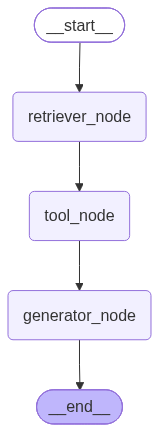

In [20]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("tool_node", tool_node)
graph.add_node("generator_node", generator_node)

graph.add_edge(START, "retriever_node")
graph.add_edge("retriever_node", "tool_node")
graph.add_edge("tool_node", "generator_node")
graph.add_edge("generator_node", END)

knowledge_assistant = graph.compile()
knowledge_assistant

In [21]:
#What is INVOLVE an AI powered on demand local service platform? examine a pdf named 29_Paper.pdf inside pdf folder of docs that is inside of C drive then Faheem then My_Programs Rag_Beginners
response = knowledge_assistant.invoke({
    "query": "What is Langchain and how it is related with langgraph",
    "question": "",
    "answer": "",
    "path": "",
    "tool_calls": [],
    "document": []
})
response


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.6-flash' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-2.6-flash is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}

In [ ]:
from memory import LocalMemory
from datetime import datetime
memory = LocalMemory()

save_data = memory.save_memory(response["question"], response["result"][0]["text"], datetime.now().isoformat())

Question: How do I create a retriever in LangGraph?
Answer: You can create a retriever node and connect it to the graph.
{'timestamp': '2026-08-08T16:54:06.677607', 'question': 'How do I create a retriever in LangGraph?', 'answer': 'You can create a retriever node and connect it to the graph.'}

